In [21]:
import pandas as pd
import matplotlib.pyplot as plt


In [25]:
df = pd.read_csv('trends.csv', skiprows=2)

print(df.head(10))

   2021-06-01  18  2   43  13  2.1
0  2021-07-01  20  2   47  14    3
1  2021-08-01  25  2   60   8    2
2  2021-09-01  28  2   45  12    2
3  2021-10-01  24  2   47  16    3
4  2021-11-01  27  2   83  17    3
5  2021-12-01  31  2  100  19    4
6  2022-01-01  28  2   49  14    3
7  2022-02-01  27  3   67  16    3
8  2022-03-01  28  3   49  14    3
9  2022-04-01  25  2   61  19    3


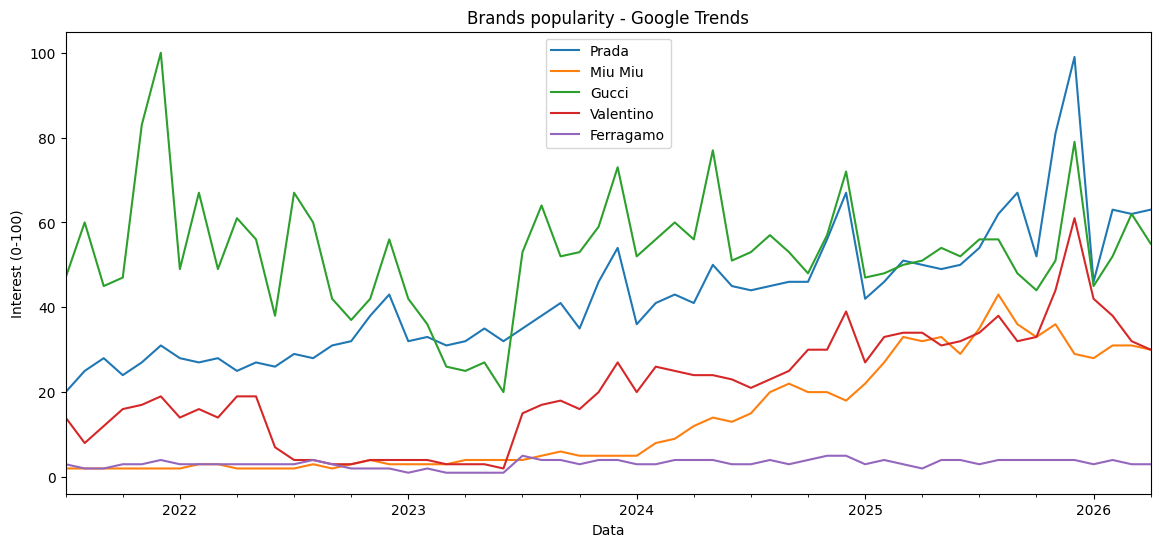

In [ ]:
df.columns = ['Data', 'Prada', 'Miu Miu', 'Gucci', 'Valentino', 'Ferragamo']

df['Data'] = pd.to_datetime(df['Data'])

df = df.set_index('Data')

# Plot
df.plot(figsize=(14, 6), title='Brands popularity - Google Trends')
plt.ylabel('Interest (0-100)')
plt.xlabel('Data')
plt.show()

In [29]:
# Fashion Week show dates for each brand (February and September each year)
show_dates = {
    'Prada':     ['2021-09', '2022-02', '2022-09', '2023-02', '2023-09', '2024-02', '2024-09', '2025-02', '2025-09', '2026-02'],
    'Miu Miu':   ['2021-10', '2022-03', '2022-10', '2023-03', '2023-10', '2024-03', '2024-10', '2025-03', '2025-10', '2026-03'],
    'Gucci':     ['2021-11', '2022-05', '2022-11', '2023-02', '2023-09', '2024-02', '2024-09', '2025-02', '2025-09', '2026-02'],
    'Valentino': ['2021-10', '2022-03', '2022-07', '2023-03', '2023-07', '2024-02', '2024-09', '2025-02', '2025-09', '2026-02'],
    'Ferragamo': ['2021-09', '2022-02', '2022-09', '2023-02', '2023-09', '2024-02', '2024-09', '2025-02', '2025-09', '2026-02'],
}

print("Show dates loaded!")

Show dates loaded!


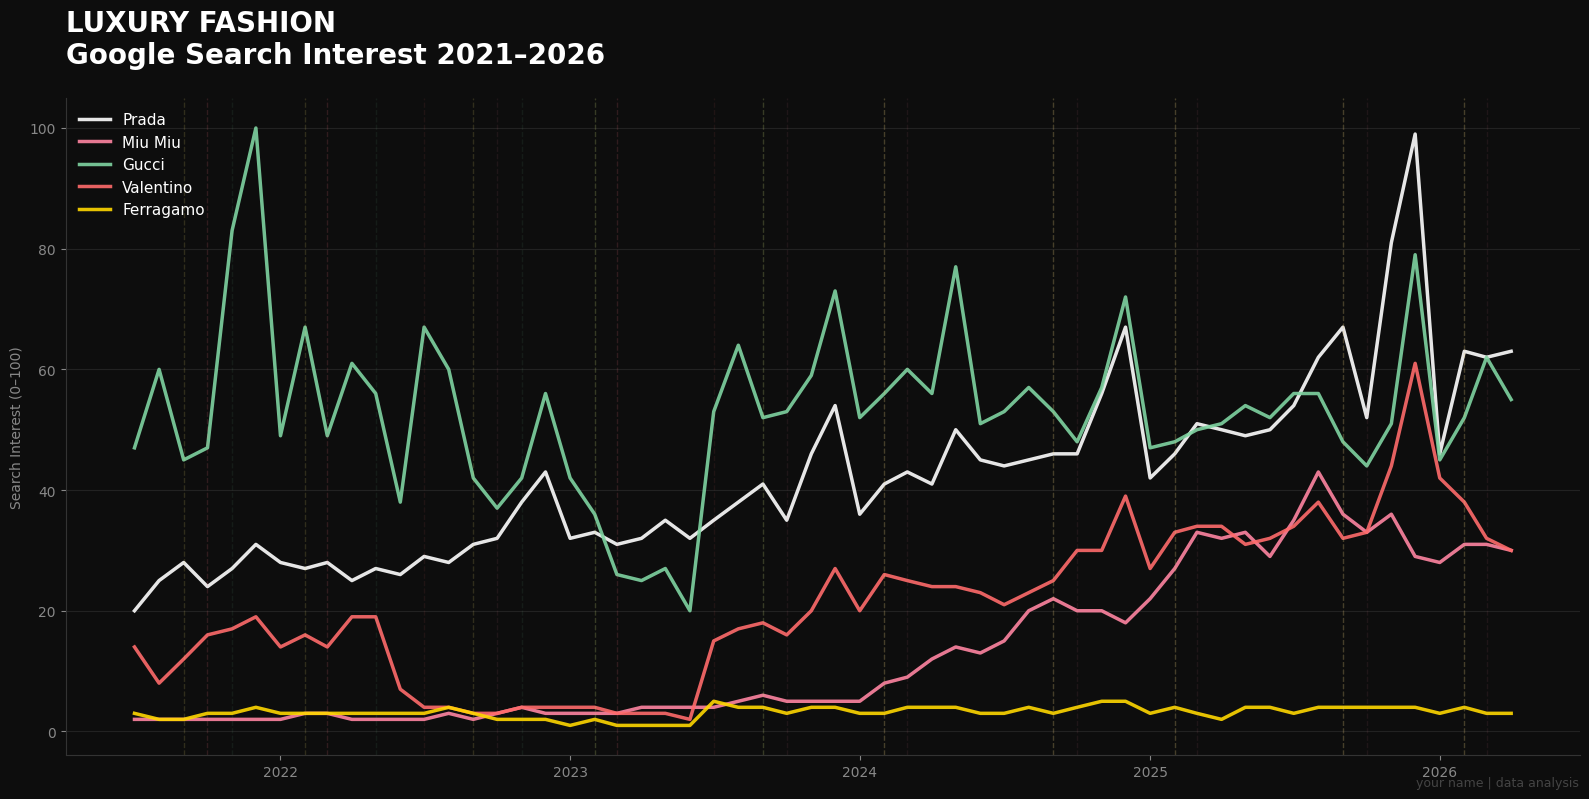

In [31]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Dark elegant style
plt.style.use('dark_background')

# Custom colors - elegant palette
colors = {
    'Prada': '#FFFFFF',
    'Miu Miu': '#FF85A1',
    'Gucci': '#7FD4A1',
    'Valentino': '#FF6B6B',
    'Ferragamo': '#FFD700'
}

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#0D0D0D')
ax.set_facecolor('#0D0D0D')

# Draw lines for each brand
for brand in ['Prada', 'Miu Miu', 'Gucci', 'Valentino', 'Ferragamo']:
    ax.plot(df.index, df[brand], 
            label=brand, 
            color=colors[brand], 
            linewidth=2.5,
            alpha=0.9)

# Add subtle show date lines
for brand, dates in show_dates.items():
    for date in dates:
        ax.axvline(
            x=pd.to_datetime(date),
            color=colors[brand],
            alpha=0.08,
            linewidth=1,
            linestyle='--'
        )

# Elegant typography
ax.set_title('LUXURY FASHION\nGoogle Search Interest 2021–2026', 
             fontsize=20, 
             color='white',
             fontweight='bold',
             pad=25,
             loc='left')

ax.set_ylabel('Search Interest (0–100)', color='#888888', fontsize=10)
ax.set_xlabel('')

# Clean up the axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')
ax.tick_params(colors='#888888')
ax.yaxis.label.set_color('#888888')

# Format x axis as years
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

# Legend
legend = ax.legend(loc='upper left', 
                   frameon=False,
                   fontsize=11,
                   labelcolor='white')

# Subtle grid
ax.yaxis.grid(True, color='#222222', linewidth=0.8)
ax.set_axisbelow(True)

# Watermark - your personal brand!
fig.text(0.99, 0.01, 'your name | data analysis', 
         ha='right', 
         color='#444444', 
         fontsize=9)

plt.tight_layout()
plt.savefig('luxury_trends.png', dpi=300, bbox_inches='tight', facecolor='#0D0D0D')
plt.show()